# Prototype: Micro Coral Area Measurement
This notebook seeds the prototype for measuring micro-coral areas in mm².

Step 1: import libraries and list images in `data/photos-micro-corals`.

In [1]:
# Imports
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2

plt.rcParams['figure.dpi'] = 100

# Data folder
data_dir = Path('../data/photos-micro-corals')
if not data_dir.exists():
    raise FileNotFoundError(f'Folder not found: {data_dir}')

# gather image files
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}
img_paths = sorted([p for p in data_dir.rglob('*') if p.suffix.lower() in IMG_EXTS])
print(f'Found {len(img_paths)} image(s) in {data_dir}')
img_paths[:20]

Found 20 image(s) in ../data/photos-micro-corals


[PosixPath('../data/photos-micro-corals/PB300143.JPG'),
 PosixPath('../data/photos-micro-corals/PB300169.JPG'),
 PosixPath('../data/photos-micro-corals/PB300170.JPG'),
 PosixPath('../data/photos-micro-corals/PB300172.JPG'),
 PosixPath('../data/photos-micro-corals/PB300174.JPG'),
 PosixPath('../data/photos-micro-corals/PB300176.JPG'),
 PosixPath('../data/photos-micro-corals/PB300177.JPG'),
 PosixPath('../data/photos-micro-corals/PB300179.JPG'),
 PosixPath('../data/photos-micro-corals/PB300180.JPG'),
 PosixPath('../data/photos-micro-corals/PB300182.JPG'),
 PosixPath('../data/photos-micro-corals/PB300183.JPG'),
 PosixPath('../data/photos-micro-corals/PB300187.JPG'),
 PosixPath('../data/photos-micro-corals/PB300190.JPG'),
 PosixPath('../data/photos-micro-corals/PB300191.JPG'),
 PosixPath('../data/photos-micro-corals/PB300193.JPG'),
 PosixPath('../data/photos-micro-corals/PB300196.JPG'),
 PosixPath('../data/photos-micro-corals/PB300198.JPG'),
 PosixPath('../data/photos-micro-corals/PB300199

Sample: PB300143.JPG — size=4000x2672 px — mode=RGB


,path,name,width_px,height_px,mode,bytes
0,../data/photos-micro-corals/PB300143.JPG,PB300143.JPG,4000,2672,RGB,5448261
1,../data/photos-micro-corals/PB300169.JPG,PB300169.JPG,4000,2672,RGB,6151768
2,../data/photos-micro-corals/PB300170.JPG,PB300170.JPG,4000,2672,RGB,5751228
3,../data/photos-micro-corals/PB300172.JPG,PB300172.JPG,4000,2672,RGB,5562958
4,../data/photos-micro-corals/PB300174.JPG,PB300174.JPG,4000,2672,RGB,5712428
5,../data/photos-micro-corals/PB300176.JPG,PB300176.JPG,4000,2672,RGB,5545814
6,../data/photos-micro-corals/PB300177.JPG,PB300177.JPG,4000,2672,RGB,5623240
7,../data/photos-micro-corals/PB300179.JPG,PB300179.JPG,4000,2672,RGB,5617639
8,../data/photos-micro-corals/PB300180.JPG,PB300180.JPG,4000,2672,RGB,5537749
9,../data/photos-micro-corals/PB300182.JPG,PB300182.JPG,4000,2672,RGB,5691974


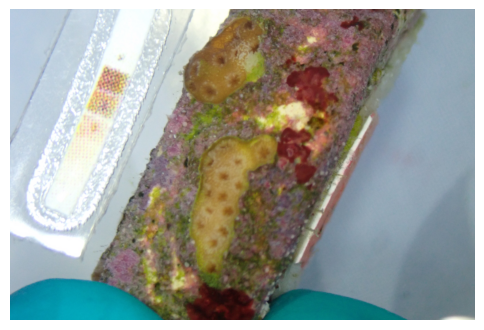

In [2]:
# Display first image (if any) and basic metadata
if len(img_paths) == 0:
    print('No images found to display')
else:
    p = img_paths[0]
    with Image.open(p) as im:
        w, h = im.size
        mode = im.mode
    print(f'Sample: {p.name} — size={w}x{h} px — mode={mode}')
    img = Image.open(p).convert('RGB')
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')

# Create a DataFrame summarising all images
rows = []
for p in img_paths:
    try:
        with Image.open(p) as im:
            w, h = im.size
            mode = im.mode
    except Exception as e:
        w, h, mode = None, None, None
    rows.append({
        'path': str(p),
        'name': p.name,
        'width_px': w,
        'height_px': h,
        'mode': mode,
        'bytes': p.stat().st_size
    })
df = pd.DataFrame(rows)
df.head(40)

In [14]:
def get_image(uploaded_file):
    image = cv2.imread(str(uploaded_file))

    # Read the file into a byte stream
    # file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    
    # Decode the file bytes to an image
    # image = cv2.imdecode(image, cv2.IMREAD_COLOR)
    
    # Convert color from BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Apply any preprocessing like histogram preprocessing
    # image = preprocess_histograms(image=image)

    # Get the dimensions of the image
    height, width = image.shape[:2]

    # Calculate the aspect ratio
    aspect_ratio = width / height

    # Define the new width and height while maintaining the aspect ratio
    new_width = 1800
    new_height = int(new_width / aspect_ratio)

    # Resize the image
    image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)

    # image = cv2.resize(image, (3600, 2400), interpolation=cv2.INTER_AREA)

    
    return image

In [4]:
# Rule-based detection and benchmarking of the color scale bar
import math
import sys
import torch
from pathlib import Path
import numpy as np
import cv2
import pandas as pd
import os


In [ ]:

# ensure segment_anything package is importable (repo contains it)
sys.path.append('..')
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator


In [6]:

# small vit_b checkpoint path (already added to `checkpoints/`)
checkpoint = Path('../checkpoints/sam_vit_b_01ec64.pth')
if not checkpoint.exists():
    raise FileNotFoundError(f'SAM checkpoint not found: {checkpoint}')

# force use of GPU device 1
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_type = 'vit_b'
print('Loading SAM', model_type, 'onto', device)
# attempt direct build with checkpoint; fall back to non-strict load on mismatch
try:
    sam = sam_model_registry[model_type](checkpoint=str(checkpoint))
    sam.to(device=device)
except Exception as e:
    print('Primary SAM build failed:', e)
    print('Building model without checkpoint and attempting to load state_dict with strict=False')
    sam = sam_model_registry[model_type](checkpoint='')
    state = torch.load(str(checkpoint), map_location='cpu')
    if isinstance(state, dict) and 'model' in state:
        state = state['model']
    sam.load_state_dict(state, strict=False)
    sam.to(device=device)
# create automatic mask generator with conservative defaults
# mask_generator = SamAutomaticMaskGenerator()
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.72,
    stability_score_thresh=0.62,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,
)


Loading SAM vit_b onto cuda


/home/barradd/Documents/GitHub/Coral-CAT-Coral-Color-Assessment-Tool/notebooks/../segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict

In [7]:

# output dirs
out_root = Path('../data/interim/benchmark/sam')
masks_dir = out_root / 'masks'
crops_dir = out_root / 'crops'
images_dir = out_root / 'images'
for d in (out_root, masks_dir, crops_dir, images_dir):
    d.mkdir(parents=True, exist_ok=True)


In [20]:

rows = []

for p in img_paths:
    print('Processing', p.name)
    # img_bgr = cv2.imread(str(p))
    # if img_bgr is None:
    #     print('Failed to read', p)
    #     continue
    # img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # print ('Reading image with OpenCV and converting to RGB', p)               

    img_rgb = get_image(str(p))
    # run SAM mask generator (expects HxWxC uint8 RGB)
    masks = mask_generator.generate(img_rgb)
    # save original image copy to images_dir for traceability
    img_save_path = images_dir / p.name
    # cv2.imwrite(str(img_save_path), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    for i, m in enumerate(masks):
        seg = m.get('segmentation')
        area = int(m.get('area', np.count_nonzero(seg)))
        if area > 300000: # filter out masks smaller than 10% of 3600x2400 (full image size)
            bbox = m.get('bbox', None)
            stability = float(m.get('stability_score', m.get('stability_score', 0))) if m.get('stability_score') is not None else None
            # save mask as PNG (binary)
            mask_path = masks_dir / f'{p.stem}_mask_{i}.png'
            cv2.imwrite(str(mask_path), (seg.astype('uint8') * 255))
            # save cropped RGB image for mask bbox if available
            if bbox is not None and len(bbox) == 4:
                x, y, w, h = map(int, bbox)
                crop = img_rgb[y:y+h, x:x+w].copy()
                if crop.size > 0:
                    crop_path = crops_dir / f'{p.stem}_crop_{i}.png'
                    cv2.imwrite(str(crop_path), cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
            else:
                crop_path = None
            rows.append({
                'image': str(p),
                'mask_id': i,
                'area_px': area,
                'bbox': bbox,
                'stability_score': stability,
                'mask_path': str(mask_path),
                'crop_path': str(crop_path) if bbox is not None else None
            })
        else:
            print(f'Filtered out mask {i} for {p.name} due to small area ({area} px)')

# save metadata CSV
meta_df = pd.DataFrame(rows)
meta_csv = out_root / 'sam_segments_metadata.csv'
meta_df.to_csv(meta_csv, index=False)
print('Saved SAM metadata to', meta_csv)


Processing PB300143.JPG
Filtered out mask 0 for PB300143.JPG due to small area (10497 px)
Filtered out mask 1 for PB300143.JPG due to small area (12272 px)
Filtered out mask 2 for PB300143.JPG due to small area (16253 px)
Filtered out mask 3 for PB300143.JPG due to small area (1802 px)
Filtered out mask 4 for PB300143.JPG due to small area (3393 px)
Filtered out mask 5 for PB300143.JPG due to small area (21566 px)
Filtered out mask 6 for PB300143.JPG due to small area (5723 px)
Filtered out mask 7 for PB300143.JPG due to small area (5176 px)
Filtered out mask 8 for PB300143.JPG due to small area (43307 px)
Filtered out mask 9 for PB300143.JPG due to small area (20744 px)
Filtered out mask 10 for PB300143.JPG due to small area (1362 px)
Filtered out mask 11 for PB300143.JPG due to small area (623 px)
Filtered out mask 12 for PB300143.JPG due to small area (12217 px)
Filtered out mask 13 for PB300143.JPG due to small area (1463 px)
Filtered out mask 14 for PB300143.JPG due to small area 